In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('2agosto-dic2021.csv', engine="python", on_bad_lines="skip", quoting=3)

## Exploratory Data Analysis

In [3]:
df.sample(5)

,MAC,"""weekday""","""fecha_servidor""","""fecha_esp32""","""voltaje""","""corriente""","""potencia""","""frecuencia""","""energia""","""fp""","""ESP32_temp""","""WORKSTATION_CPU""","""WORKSTATION_CPU_POWER""","""WORKSTATION_CPU_TEMP""","""WORKSTATION_GPU""","""WORKSTATION_GPU_POWER""","""WORKSTATION_GPU_TEMP""","""WORKSTATION_RAM""","""WORKSTATION_RAM_POWER"""
424694,"""3C:61:05:12:96:30""","""2""","""2021-08-10 19:15:12""","""2021-08-10 19:15:12""","""120""","""0.99""","""105.7""","""60""","""180.7""","""0.89""","""27.78""","""4.17""","""37.87""","""27""","""0""","""35""","""14.32""","""39.17""","""8.04"""
2379521,"""3C:61:05:12:96:30""","""7""","""2021-09-19 07:04:47""","""2021-09-19 07:04:47""","""120.1""","""0.68""","""76.2""","""60""","""278.72""","""0.93""","""26.11""","""4.44""","""34.72""","""25""","""0""","""33""","""14.32""","""35.28""","""2.83"""
2110187,"""3C:61:05:12:96:30""","""7""","""2021-09-12 19:28:22""","""2021-09-12 19:28:22""","""120""","""0.74""","""84.3""","""59.9""","""266.86""","""0.94""","""27.78""","""4.74""","""38.16""","""27""","""0""","""36""","""14.23""","""40.26""","""6.9"""
2126932,"""3C:61:05:12:96:30""","""1""","""2021-09-13 00:25:37""","""2021-09-13 00:25:37""","""120.1""","""0.76""","""86.4""","""60""","""267.29""","""0.95""","""27.22""","""5.64""","""38.19""","""28""","""0""","""35""","""14.43""","""40.12""","""6.73"""
2225779,"""3C:61:05:12:96:30""","""2""","""2021-09-14 05:40:07""","""2021-09-14 05:40:07""","""120.1""","""0.76""","""87.2""","""60""","""269.85""","""0.95""","""26.67""","""4.43""","""38.25""","""25""","""0""","""34""","""14.42""","""39.88""","""6.14"""


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3178051 entries, 0 to 3178050
Data columns (total 19 columns):
 #   Column                   Dtype
---  ------                   -----
 0   MAC                      str  
 1   "weekday"                str  
 2   "fecha_servidor"         str  
 3   "fecha_esp32"            str  
 4   "voltaje"                str  
 5   "corriente"              str  
 6   "potencia"               str  
 7   "frecuencia"             str  
 8   "energia"                str  
 9   "fp"                     str  
 10  "ESP32_temp"             str  
 11  "WORKSTATION_CPU"        str  
 12  "WORKSTATION_CPU_POWER"  str  
 13  "WORKSTATION_CPU_TEMP"   str  
 14  "WORKSTATION_GPU"        str  
 15  "WORKSTATION_GPU_POWER"  str  
 16  "WORKSTATION_GPU_TEMP"   str  
 17  "WORKSTATION_RAM"        str  
 18  "WORKSTATION_RAM_POWER"  str  
dtypes: str(19)
memory usage: 913.1 MB


In [5]:
df.describe()

,MAC,"""weekday""","""fecha_servidor""","""fecha_esp32""","""voltaje""","""corriente""","""potencia""","""frecuencia""","""energia""","""fp""","""ESP32_temp""","""WORKSTATION_CPU""","""WORKSTATION_CPU_POWER""","""WORKSTATION_CPU_TEMP""","""WORKSTATION_GPU""","""WORKSTATION_GPU_POWER""","""WORKSTATION_GPU_TEMP""","""WORKSTATION_RAM""","""WORKSTATION_RAM_POWER"""
count,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051,3178051
unique,2,7,2848409,2853358,43,1069,1199,8,31966,30,81,2571,1206,68,34,18,319,3486,1684
top,"""3C:61:05:12:96:30""","""4""","""2021-11-25 20:48:31""","""2021-12-02 20:36:31""","""120""","""1.03""","""66.1""","""60""","""171.89""","""0.9""","""53.3333""","""0""","""0""","""27""","""0""","""34""","""0""","""0""","""0"""
freq,2852499,575973,30,4,798664,274904,81239,2063234,6039,1430986,660831,431827,431825,740021,3049100,1139946,739091,431827,431827


### Convert Column names to English

In [6]:

# Strip stray quote characters from column names
df.columns = df.columns.str.replace('"', '', regex=False)

# Rename to clear English names
rename_map = {
    'MAC': 'device_mac',
    'weekday': 'weekday',
    'fecha_servidor': 'server_timestamp',
    'fecha_esp32': 'esp32_timestamp',
    'voltaje': 'voltage_v',
    'corriente': 'current_a',
    'potencia': 'power_w',
    'frecuencia': 'frequency_hz',
    'energia': 'energy_kwh',
    'fp': 'power_factor',
    'ESP32_temp': 'esp32_temp_c',
    'WORKSTATION_CPU': 'cpu_utilization_pct',
    'WORKSTATION_CPU_POWER': 'cpu_power_w',
    'WORKSTATION_CPU_TEMP': 'cpu_temp_c',
    'WORKSTATION_GPU': 'gpu_utilization_pct',
    'WORKSTATION_GPU_POWER': 'gpu_power_w',
    'WORKSTATION_GPU_TEMP': 'gpu_temp_c',
    'WORKSTATION_RAM': 'ram_utilization_pct',
    'WORKSTATION_RAM_POWER': 'ram_power_w',
}

df.rename(columns=rename_map, inplace=True)

Cleaning the Data

In [7]:
# Strip quotes from all string/object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace('"', '', regex=False)

C:\Users\User\AppData\Local\Temp\ipykernel_5748\2749427081.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [8]:
# Datetime columns
df['server_timestamp'] = pd.to_datetime(df['server_timestamp'], errors='coerce')
df['esp32_timestamp'] = pd.to_datetime(df['esp32_timestamp'], errors='coerce')

# Numeric columns
numeric_cols = [
    'voltage_v', 'current_a', 'power_w', 'frequency_hz', 'energy_kwh',
    'power_factor', 'esp32_temp_c', 'cpu_utilization_pct', 'cpu_power_w',
    'cpu_temp_c', 'gpu_utilization_pct', 'gpu_power_w', 'gpu_temp_c',
    'ram_utilization_pct', 'ram_power_w'
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# weekday is likely categorical/int
df['weekday'] = pd.to_numeric(df['weekday'], errors='coerce').astype('Int64')

Find Correlation in data

In [9]:
numeric_cols = [
    'voltage_v', 'current_a', 'power_w', 'frequency_hz', 'energy_kwh',
    'power_factor', 'esp32_temp_c', 'cpu_utilization_pct', 'cpu_power_w',
    'cpu_temp_c', 'gpu_utilization_pct', 'gpu_power_w', 'gpu_temp_c',
    'ram_utilization_pct', 'ram_power_w'
]

# Dictionary of correlation matrices, one per server
correlations = {}
for mac, group in df.groupby('device_mac'):
    correlations[mac] = group[numeric_cols].corr()

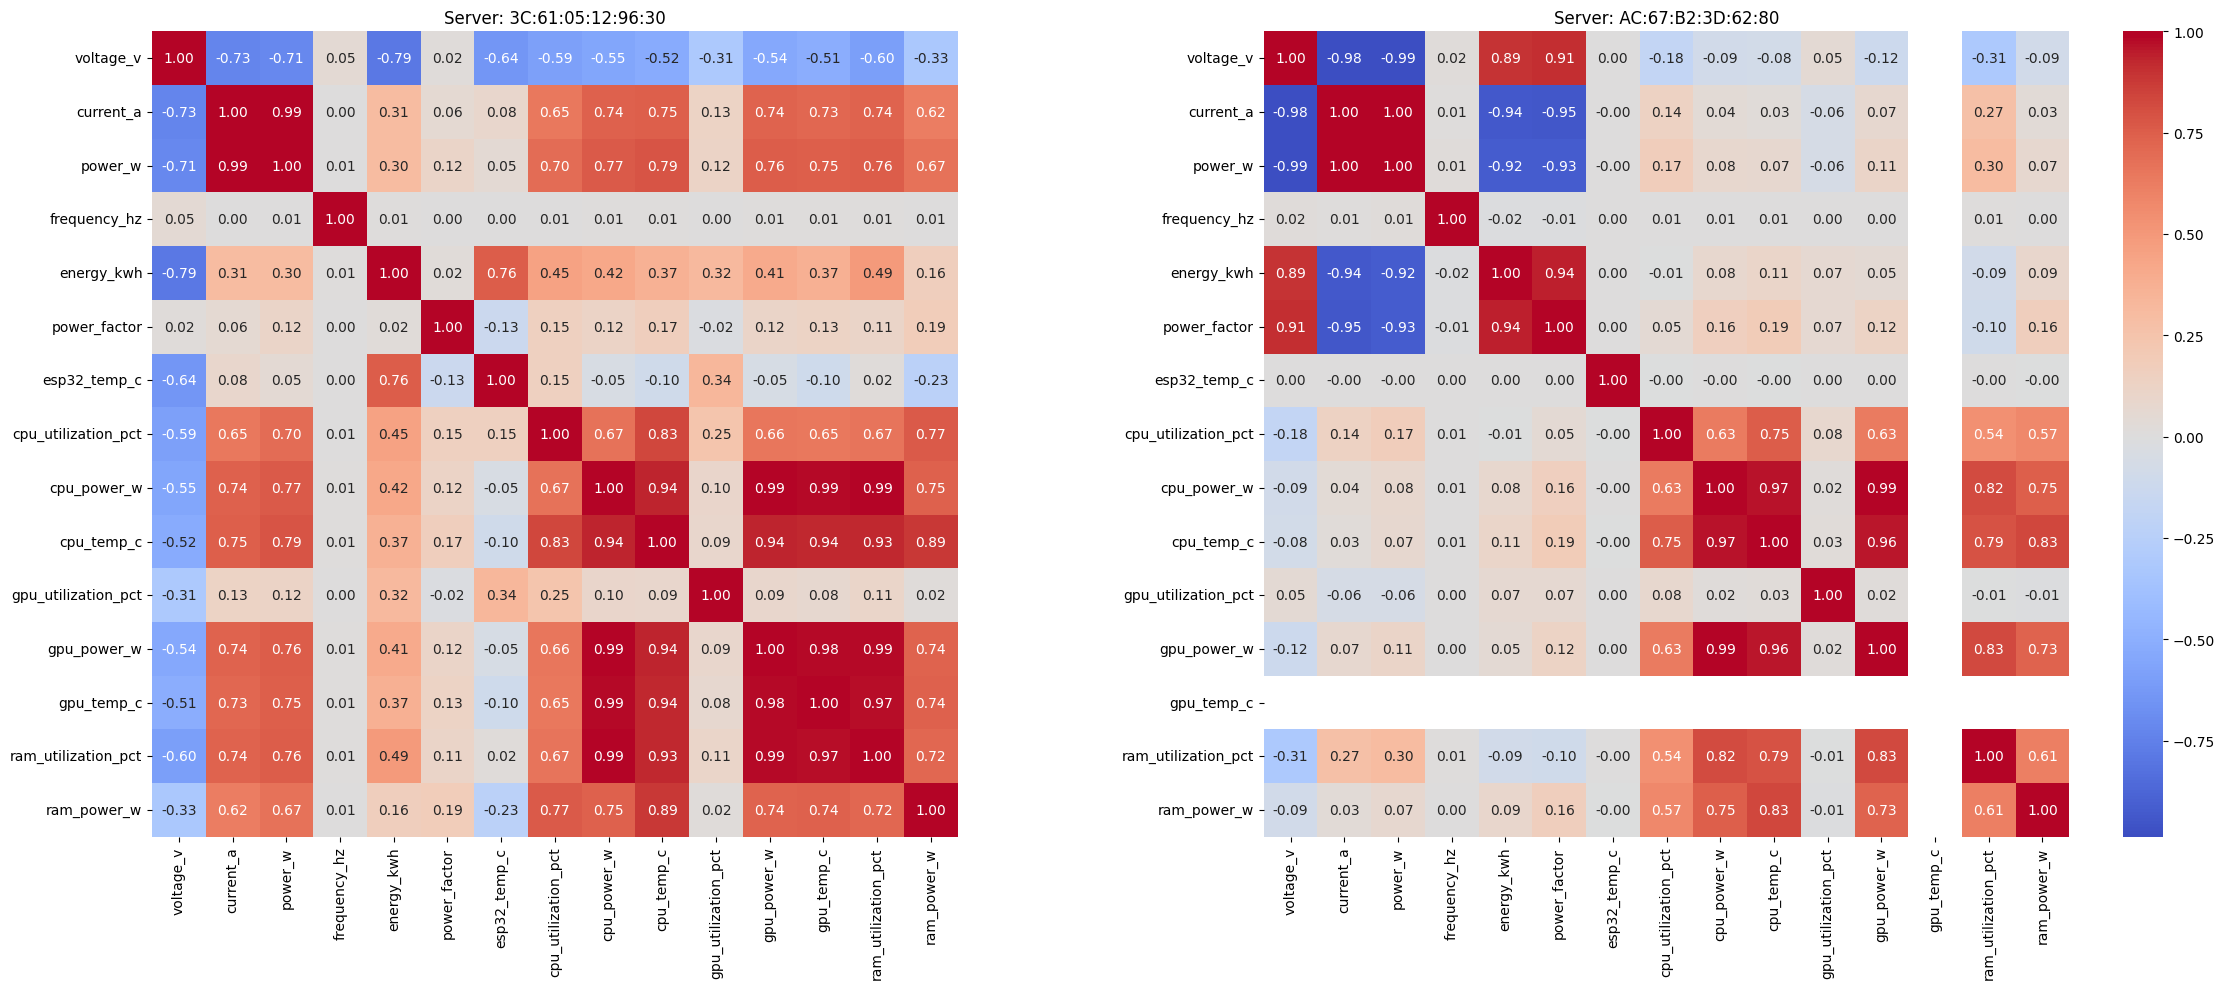

In [10]:
macs = df['device_mac'].unique()
fig, axes = plt.subplots(1, len(macs), figsize=(12 * len(macs), 10))

if len(macs) == 1:
    axes = [axes]

for ax, mac in zip(axes, macs):
    sns.heatmap(correlations[mac], annot=True, fmt=".2f", cmap="coolwarm",
                center=0, square=True, ax=ax, cbar=(ax == axes[-1]))
    ax.set_title(f"Server: {mac}")

plt.tight_layout()
plt.savefig("correlation_comparison_both_servers.png")
plt.show()